# Credit Card Fraud Detection

Imagine that you work for a financial institution and part of your job is to build a model that predicts if a credit card transaction is fraudulent or not. You can model the problem as a binary classification problem. A transaction belongs to the positive class (1) if it is a fraud, otherwise it belongs to the negative class (0).

You have access to transactions that occured over a certain period of time. The majority of the transactions are normally legitimate and only a small fraction are non-legitimate. Thus, typically you have access to a dataset that is highly unbalanced. This is also the case of the current dataset: only 492 transactions out of 284,807 are fraudulent (the positive class - the frauds - accounts for 0.172% of all transactions).

This is a Kaggle dataset. You can find this "Credit Card Fraud Detection" dataset from the following link:

<a href="https://www.kaggle.com/mlg-ulb/creditcardfraud">Credit Card Fraud Detection</a>.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import roc_auc_score


In [3]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv')
print(f'Num of Observations: {df.shape[0]}')
print(f'Num of Columns: {df.shape[1]}')

Num of Observations: 284807
Num of Columns: 31


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

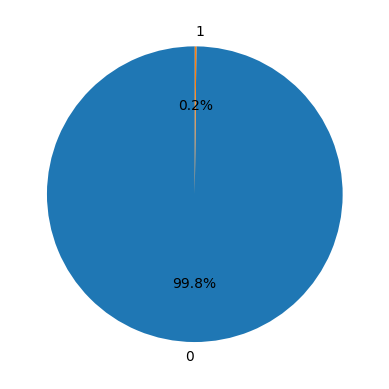

In [21]:
labels = df['Class'].unique()

sizes = df['Class'].value_counts()


plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.show()

**Data Preprocessing**

For better practice and better performance let's normalize the dataset

In [26]:
df.iloc[:,1:30] = StandardScaler().fit_transform(df.iloc[:,1:30])

X = df.iloc[:,1:30].values
y = df['Class'].values

X = normalize(X,norm= 'l1')

print(f'X shape: {X.shape}\ny shape: {y.shape}')

X shape: (284807, 29)
y shape: (284807,)


**Train Test Split**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=42, stratify=y)

**Decission Tree Classifier**

In [35]:
# compute the sample weights to be used as input to the train routine so that 
# it takes into account the class imbalance present in this dataset

w_train = compute_sample_weight(class_weight='balanced',y=y_train)

Tree = DecisionTreeClassifier(max_depth=4, random_state=35)

Tree.fit(X_train,y_train, sample_weight= w_train)

DecisionTreeClassifier(max_depth=4, random_state=35)

**Support Vector Machine**

In [33]:
svm = LinearSVC(class_weight='balanced',random_state=31, loss='hinge',fit_intercept=False)

svm.fit(X_train,y_train)

C:\Users\Arkon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=31)

**Decission Tree Classifier and SVM Evaluation**

In [38]:
yhat = Tree.predict(X_test)

print(f'ROC-AUC score: {roc_auc_score(y_test,yhat):.3f}')

ROC-AUC score: 0.905


In [34]:
pred = svm.decision_function(X_test)

acc_svm = roc_auc_score(y_test,pred)

print(f'ROC-AUC: {acc_svm:.3f}')

ROC-AUC: 0.971
